In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

up_nums_path = r'C:\workspace\individual_research\yb-soc-two-body-loss\data\local\full_up_nums_momentum.npy'
down_nums_path = r'C:\workspace\individual_research\yb-soc-two-body-loss\data\local\full_down_nums_momentum.npy'

with open(up_nums_path, 'rb') as f:
    up_nums = np.load(f)
    
with open(down_nums_path, 'rb') as f:
    down_nums = np.load(f)

total_nums = up_nums + down_nums
total_nums.shape

(2048, 51, 13)

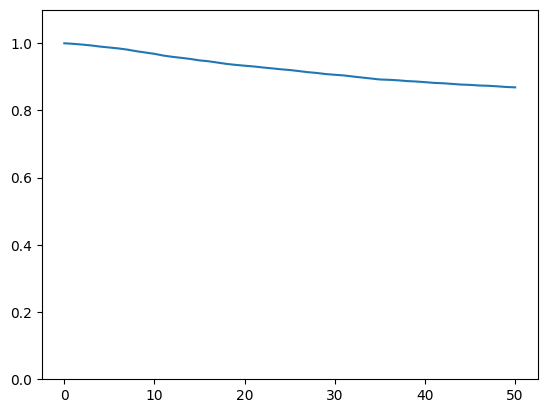

In [9]:
nums = total_nums.mean(axis=0).sum(axis=-1)
nums /= nums[0]

plt.plot(nums)
plt.ylim(0, 1.1)
plt.show()

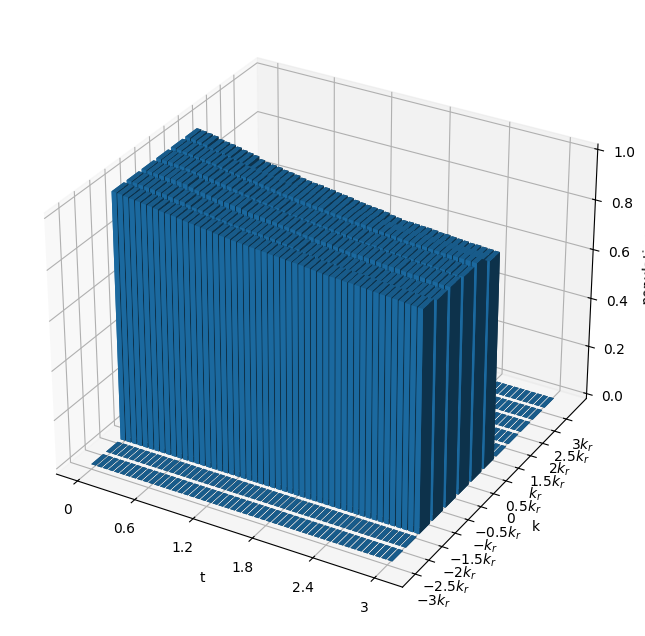

In [16]:
def generate_k_labels(n_momentum_points, k0):
    zero_index = -((n_momentum_points - 1) // 2)
    start_coeff = zero_index * k0
    coeffs = [start_coeff + i * k0 for i in range(n_momentum_points)]
    result_list = []
    for c in coeffs:
        if c == 0:
            # 계수가 0일 경우
            formatted_str = "$0$"
        elif c == 1:
            # 계수가 1일 경우
            formatted_str = "$k_r$"
        elif c == -1:
            # 계수가 -1일 경우
            formatted_str = "$-k_r$"
        else:
            # 그 외의 경우 (정수 및 실수)
            # 계수가 2.0, -3.0과 같이 정수이면 소수점(.0)을 제거합니다.
            if c == int(c):
                num_str = str(int(c))
            else:
                num_str = str(c)
            formatted_str = f"${num_str}k_r$"
        result_list.append(formatted_str)
    return result_list
k_tick_labels = generate_k_labels(13, 0.5)

data = total_nums.mean(axis=0).T

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

rows, cols = data.shape
xpos = np.arange(cols)
ypos = np.arange(rows)

xpos, ypos = np.meshgrid(xpos, ypos)

xpos = xpos.flatten()
ypos = ypos.flatten()

zpos = np.zeros_like(xpos)

dz = data.flatten()

dx = 0.8 * np.ones_like(zpos)
dy = 0.8 * np.ones_like(zpos)

ax.bar3d(xpos, ypos, zpos, dx, dy, dz, shade=True)

ax.set_xlabel('t')
ax.set_xticks([0, 10, 20, 30, 40, 50])
ax.set_xticklabels([0, 3/5, 6/5, 9/5, 12/5, 3])
ax.set_ylabel('k')
ax.set_yticks(np.arange(rows))
ax.set_yticklabels(k_tick_labels)
ax.set_zlabel('population')
ax.set_title('')

plt.savefig('plot.png')
plt.show()

In [17]:
up_nums_mean = up_nums.mean(axis=0)
down_nums_mean = down_nums.mean(axis=0)


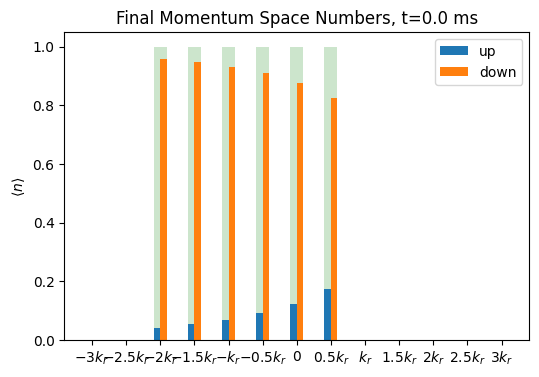

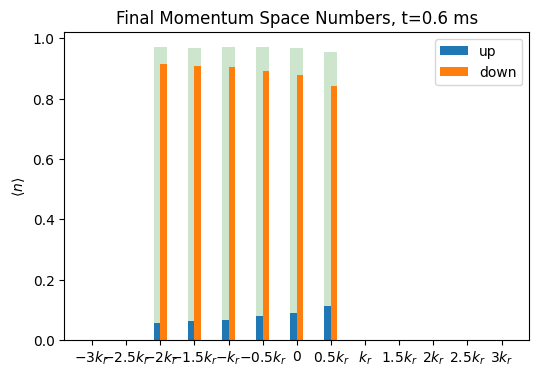

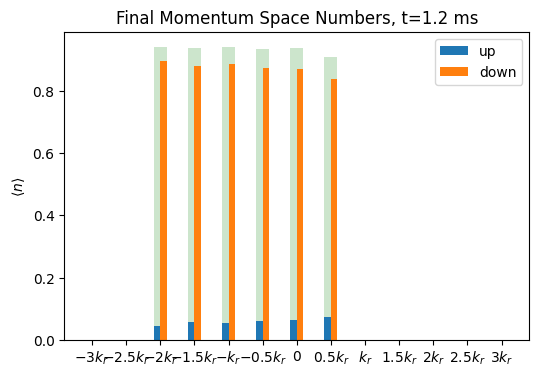

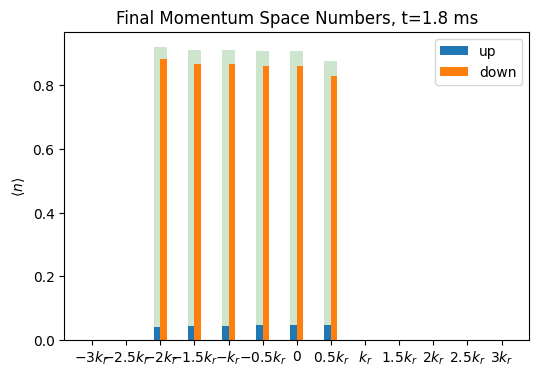

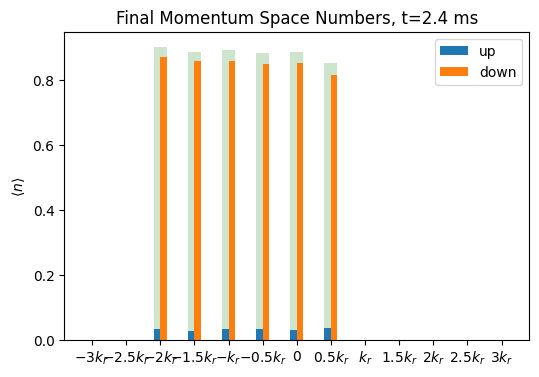

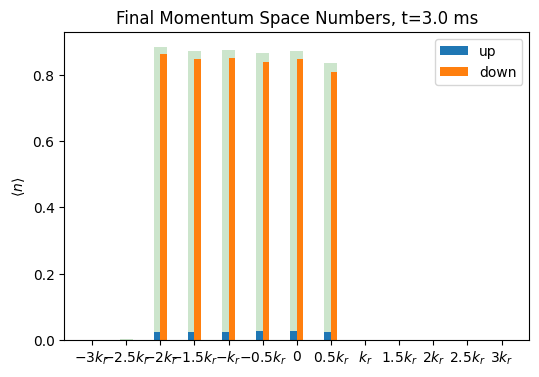

In [ ]:
from quant_mech.plot_utils import plot_numbers, plot_fractions

for i in range(0, 51, 10):
    plot_numbers(
        up_nums_mean[i],
        down_nums_mean[i],
        tick_labels=k_tick_labels,
        title=f"Final Momentum Space Numbers, t={i * 3 / 50} ms",
    ) 

In [ ]:
up_nums_canon = np.roll(up_nums_mean, shift=-2)
down_nums_canon = np.roll(down_nums_mean, shift=2)
total_nums_canon = up_nums_canon + down_nums_canon

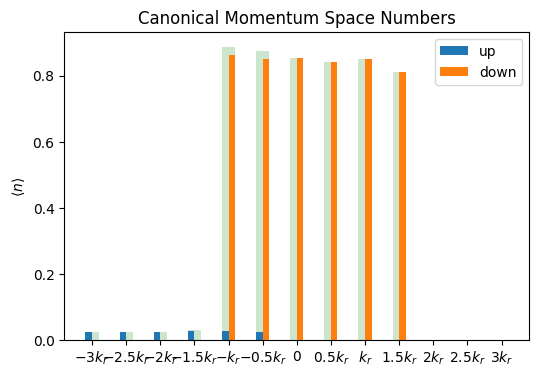

In [28]:
plot_numbers(
    up_nums_canon[-1],
    down_nums_canon[-1],
    tick_labels=k_tick_labels,
    title="Canonical Momentum Space Numbers"
)

In [ ]:

def calc_loss_frac(initial, final):
    return np.where(np.abs(initial) < 1e-12, np.zeros_like(initial), 1 - final / initial)

loss_frac_up_canon = calc_loss_frac(up_nums_canon[0], up_nums_canon[-1])
loss_frac_down_canon = calc_loss_frac(down_nums_canon[0], down_nums_canon[-1])
loss_frac_total_canon = calc_loss_frac(total_nums_canon[0], total_nums_canon[-1])

